# Step 3 Topic Modeling for All EPB Abstracts

In [1]:
#regular packages
import pandas as pd
import os

# 0 Load Data
## 0.1 Combine All


In [2]:
#set path
directory_path = 'data_papers'
# List all files in the directory
files = os.listdir(directory_path)

# Filter out only CSV files
csv_files = [file for file in files if file.endswith('.csv')]

full_df = pd.DataFrame()
# Iterate through each CSV file and read it using pandas
for csv_file in csv_files:
    file_path = os.path.join(directory_path, csv_file)
    df = pd.read_csv(file_path)
    full_df = pd.concat([full_df, df])
    
    # Now you can work with the dataframe 'df'
    # For example, print the first few rows
    print(f"Contents of {csv_file}:")
print(len(full_df))
#print(full_df.head())    

Contents of 2020s.csv:
Contents of 2000s.csv:
Contents of 1990s.csv:
Contents of 2010s.csv:
Contents of inpress.csv:
Contents of EPB_FG.csv:
Contents of 1980s.csv:
Contents of EPB_Data.csv:
Contents of 1970s.csv:
2566


In [3]:
#check Nan Value
rows_with_nan = full_df[full_df["Abstract Note"] == 'nan']
rows_with_nan

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,Programming Language,Version,System,Code,Code Number,Section,Session,Committee,History,Legislative Body


## 1 Preprocessing: Cleaning Text 

### 1.1 Removing regular stop words

along with other words
* for the abstract: only removing regular from nltk corpus
* for topic modeling results: remove more words
    - remove the words shows up more than 1000 time 
    - remove meaningless words

In [4]:
from nltk.corpus import stopwords
regular_stop_words = stopwords.words('english')

In [5]:
words_1k = ['urban', 'model', 'city', 'planning', 'study', 'data', 'spatial', 'use', 'area', 'based', 'paper', 'system']

words_other = ['result', 'ha', 'method', 'approach', 'using', 'different', 'new', 'used', 'level', 'research', 'two', 'information', 'wa', 'also', 'problem', 'effect'
                'type', 'show', 'case', 'impact', 'within', 'however', 'developed', 'application', 'high', 'context', 'relationship', 'may', 'potential', 'characteristic', 'finding', 'term', 'well', 'value', 'first', 'present', 'number', 'large', 'distribution', "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten", "finding", "built"]

additional_words = ['provide', 'technique', 'important', 'various', 'existing', 'way', 'applied', 'understanding', 'significant', 'need', 'future', 'many', 'size', 'found', 'across', 'higher', 'function', 'identify', 'presented', 'time', 'issue', 'made', 'user', 'work', 'author', 'mean', 'map', 'article']

epb_stop_words = regular_stop_words + words_1k + words_other + additional_words

## 1.2 Full Test Cleaning

In [6]:
from src.preprocessing import __general_preprocess__
from src.preprocessing import __remove_plurals__
from src.preprocessing import __remove_stopwords__
from src.preprocessing import __get_word_freq__

In [7]:
full_df['Abstract Note'] = full_df['Abstract Note'].astype(str)
full_df['abstract'] = __general_preprocess__(full_df['Abstract Note'])
full_df['abstract'] = full_df['abstract'].apply(lambda x: __remove_plurals__(x))
#full_df['abstract'] = remove_stopwords(full_df['abstract'], epb_stop_words)
full_df['abstract'] = __remove_stopwords__(full_df['abstract'], regular_stop_words)
full_freq = __get_word_freq__(full_df['abstract'])

In [8]:
full_freq

urban            3506
model            2353
planning         2044
city             1879
study            1749
                 ... 
underperforms       1
thresholding        1
imaging             1
nonurban            1
catering            1
Name: count, Length: 12931, dtype: int64

In [9]:
full_df.head() 

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,Version,System,Code,Code Number,Section,Session,Committee,History,Legislative Body,abstract
0,SDGV2F6Y,journalArticle,2020,"Huang, Bo; Zhou, Yulun; Li, Zhigang; Song, Yim...",Evaluating and characterizing urban vibrancy u...,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319828730,https://doi.org/10.1177/2399808319828730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,although people may recognize urban vibrancy s...
1,4QSHS7BK,journalArticle,2020,"Lopez, Juan Carlos G; Arnott, Richard J",Is higher-quality land developed earlier?,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319828728,https://doi.org/10.1177/2399808319828728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,higher quality land developed earlier answer q...
2,UENTSCDV,journalArticle,2020,"Humphrey, Colman; Jensen, Shane T; Small, Dyla...",Urban vibrancy and safety in Philadelphia,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319830403,https://doi.org/10.1177/2399808319830403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,statistical analysis urban environment recentl...
3,W8KSI8JB,journalArticle,2020,"Wilson, Alexander; Tewdwr-Jones, Mark",Let’s draw and talk about urban change: Deploy...,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319831290,https://doi.org/10.1177/2399808319831290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,enhancing role citizen shaping place ha longst...
4,I2D4CUJX,journalArticle,2020,"Lu, Yi; Laffan, Shawn; Pettit, Chris; Cao, Min",Land use change simulation and analysis using ...,Environment and Planning B: Urban Analytics an...,NaN,2399-8083,10.1177/2399808319830971,https://doi.org/10.1177/2399808319830971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,loss accuracy vector raster conversion ha alwa...


In [11]:
df = full_df.loc[:, ['Title', 'Author', 'abstract', 'Publication Year']]
df.head()
#df.to_csv('data_papers/cleaned_all.csv')

,Title,Author,abstract,Publication Year
0,Evaluating and characterizing urban vibrancy u...,"Huang, Bo; Zhou, Yulun; Li, Zhigang; Song, Yim...",although people may recognize urban vibrancy s...,2020
1,Is higher-quality land developed earlier?,"Lopez, Juan Carlos G; Arnott, Richard J",higher quality land developed earlier answer q...,2020
2,Urban vibrancy and safety in Philadelphia,"Humphrey, Colman; Jensen, Shane T; Small, Dyla...",statistical analysis urban environment recentl...,2020
3,Let’s draw and talk about urban change: Deploy...,"Wilson, Alexander; Tewdwr-Jones, Mark",enhancing role citizen shaping place ha longst...,2020
4,Land use change simulation and analysis using ...,"Lu, Yi; Laffan, Shawn; Pettit, Chris; Cao, Min",loss accuracy vector raster conversion ha alwa...,2020


## 2 General Stat 
### 2.1 Yearly Stat: paper published each year

In [12]:
from src.analysistools import __display_paper_yearly__

In [13]:
year_with_nan = full_df[full_df["Publication Year"] == 'nan']
year_with_nan

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,Version,System,Code,Code Number,Section,Session,Committee,History,Legislative Body,abstract


In [14]:
#Pre-processing
full_df['Publication Year'] = full_df['Publication Year'].astype(int)
full_df['amount'] = 1

In [15]:
count_df = full_df.loc[:, ["Publication Year", "amount"]]
count_df.head()

,Publication Year,amount
0,2020,1
1,2020,1
2,2020,1
3,2020,1
4,2020,1


In [16]:
yearcount = count_df.groupby(by=["Publication Year"]).sum().reset_index()
yearcount.loc[:, ['Publication Year', 'amount']].head()

,Publication Year,amount
0,1974,11
1,1975,10
2,1976,12
3,1977,14
4,1978,14


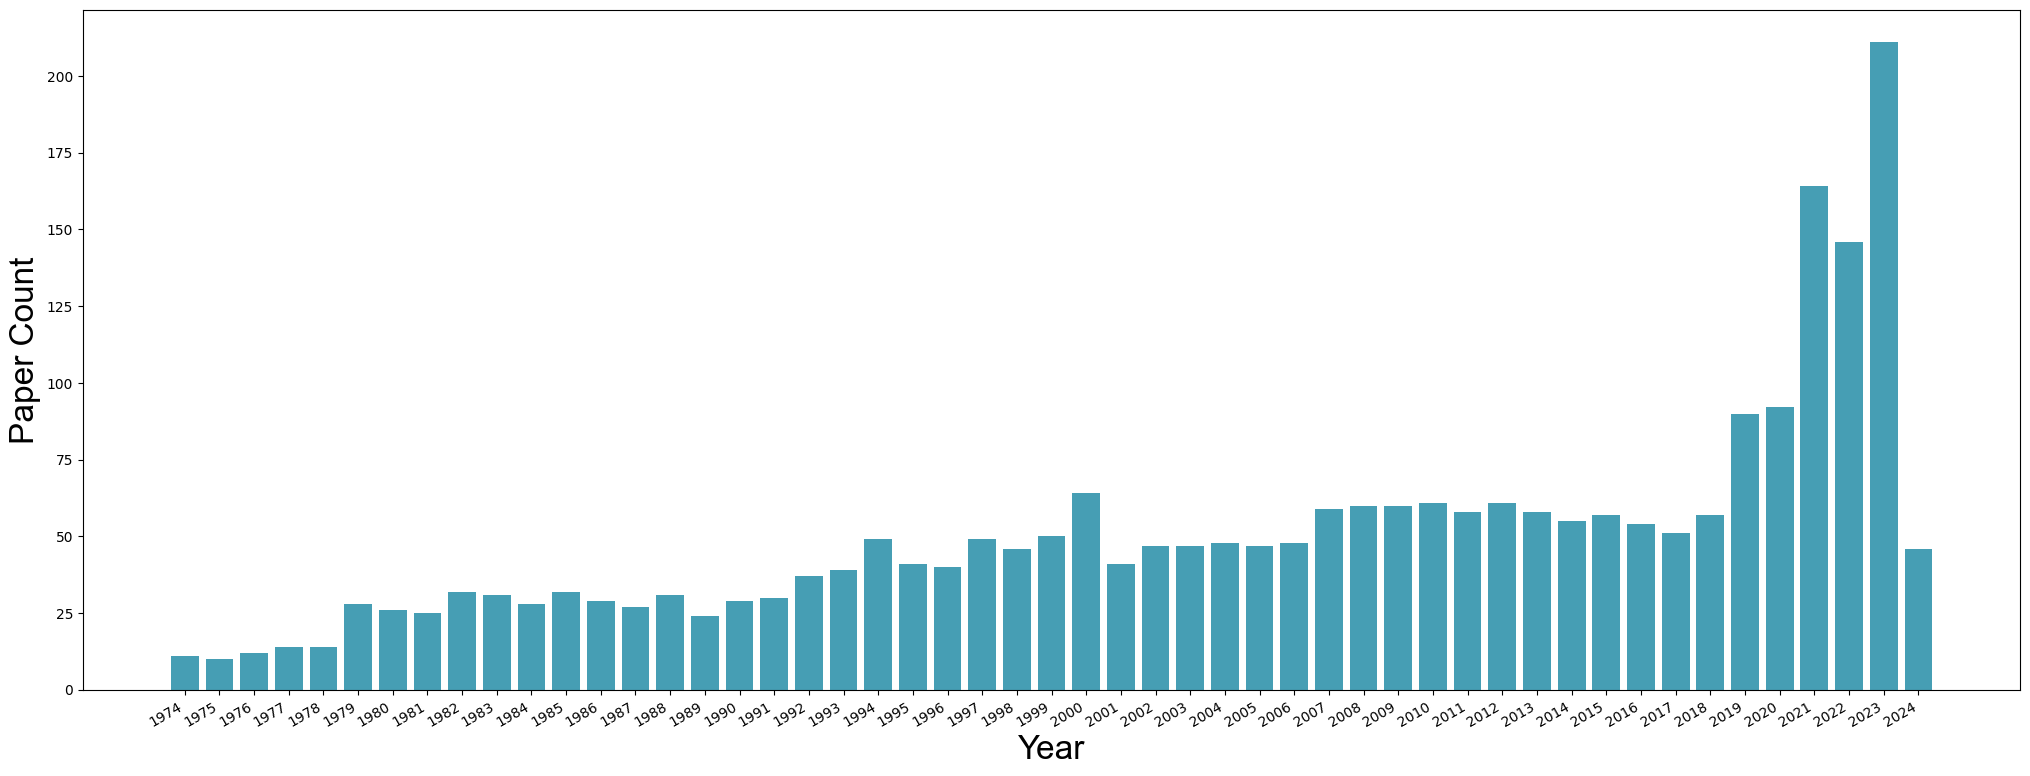

In [17]:
__display_paper_yearly__(yearcount.loc[:, ['Publication Year', 'amount']])

### 2.2 AVG Authorship by year

In [18]:
from src.analysistools import __count_authors__
from src.analysistools import __display_authorship_yearly__

In [19]:
full_df['a_amount'] = full_df['Author'].apply(lambda x: __count_authors__(x))
full_df['a_amount'].unique()

array([ 6,  2,  4,  1, 10,  3,  8,  5, 11,  7,  9, 15, 27, 12, 14])

In [20]:
author_df = full_df.loc[:, ["Publication Year", "a_amount"]]
author_df.head()

,Publication Year,a_amount
0,2020,6
1,2020,2
2,2020,4
3,2020,2
4,2020,4


In [21]:
authoravg = author_df.groupby(by=["Publication Year"]).mean().reset_index()
authoravg.loc[:, ['Publication Year', 'a_amount']].head()

,Publication Year,a_amount
0,1974,1.090909
1,1975,1.200000
2,1976,1.750000
3,1977,1.285714
4,1978,1.642857


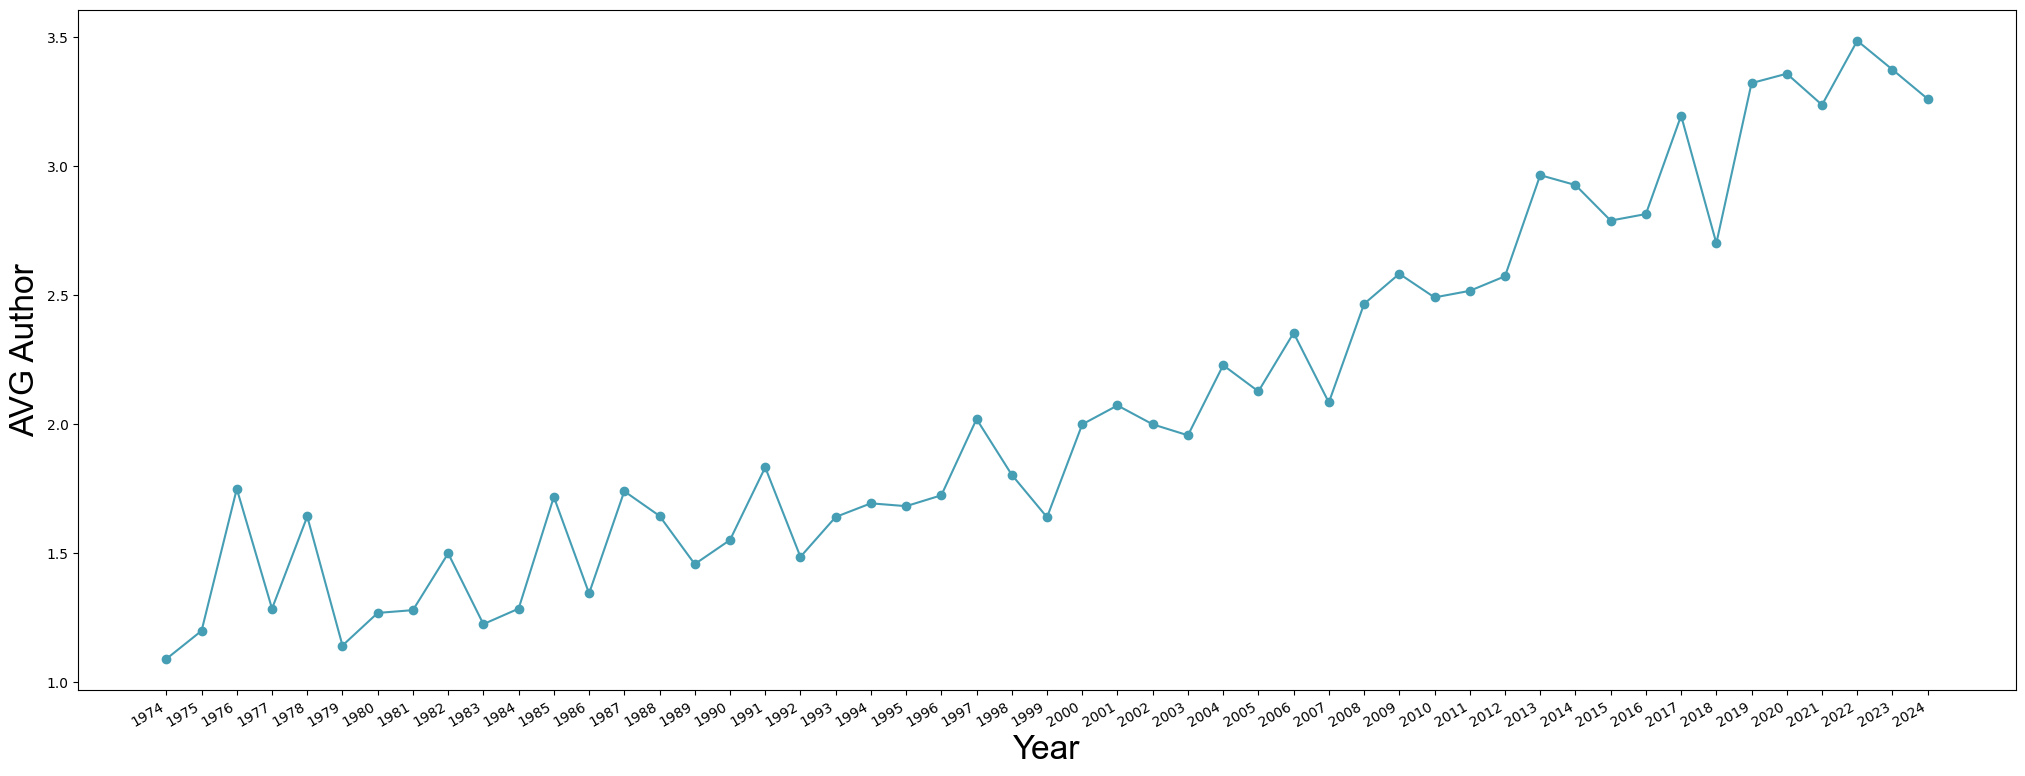

In [22]:
__display_authorship_yearly__(authoravg)

## 3 Topic Modeling 

In [68]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
#from bertopic.representation import KeyBERTInspired

In [69]:
#Documents for the inputs
docs = list(full_df.loc[:,"abstract"].values)
print("The length of the data is", len(docs))

The length of the data is 2566


In [70]:
#Sub-models
#1, Document Embedding
doc_embedding_model = SentenceTransformer("all-mpnet-base-v2") #high performance
#doc_embedding_model = SentenceTransformer("all-MiniLM-L6-v2")


#2, Dimensionality Reduction
dimensionality_reduction = UMAP(n_neighbors = 15, n_components = 5,
                  min_dist=0.0, metric='cosine', random_state = 68)#generate consistent results

#3, Document Clustering
doc_clustering_model = HDBSCAN(min_cluster_size = 10, metric= 'euclidean', cluster_selection_method='eom', prediction_data=True)
#doc_clustering_model = HDBSCAN(min_cluster_size=10, metric= 'euclidean', cluster_selection_method='eom', prediction_data=True)

#4, Topic representation: fine-tuning the topic representation
#4.1 CountVectorizer
#vectorizer_model_tuning = CountVectorizer(stop_words="english", min_df = 5)
vectorizer_model_tuning = CountVectorizer(ngram_range = (1,2), stop_words= epb_stop_words, min_df = 5)

#4.2 TF-IDF
#ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)
#ctfidf_model = ClassTfidfTransformer(bm25_weighting=True)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
#ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with
# a `bertopic.representation` model
#representation_model = KeyBERTInspired()

### 2.1.2 Results Tuning
#### 2.1.2.1 No Tuning

In [ ]:
#Application topic model
topic_model_nt = BERTopic(embedding_model = doc_embedding_model, #1
                       umap_model = dimensionality_reduction,#2
                       hdbscan_model = doc_clustering_model,#3
                       top_n_words = 15, min_topic_size=15, nr_topics='auto',
                       language = "english", calculate_probabilities = False, verbose = True)

In [ ]:
topics, probs= topic_model_nt.fit_transform(docs)

In [ ]:
freq1 = topic_model_nt.get_topic_info()#good
freq1

#### 2.1.2.2 Only CV on Non Tuning model
Apply CV after Get Results

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

#vectorizer_model_tuning_after = CountVectorizer(ngram_range = (1,2), stop_words="english", min_df = 5)
vectorizer_model_tuning_after = CountVectorizer(ngram_range = (1,2), stop_words= epb_stop_words, min_df = 5)

topic_model_nt.update_topics(docs, vectorizer_model = vectorizer_model_tuning_after)

In [ ]:
#No tuning
freq2 = topic_model_nt.get_topic_info()#good
freq2

#### 2.1.2.2Apply CV When Get Results

In [ ]:
#Application topic model
topic_model_cv = BERTopic(embedding_model = doc_embedding_model, #1
                       umap_model = dimensionality_reduction,#2
                       hdbscan_model = doc_clustering_model,#3
                       vectorizer_model = vectorizer_model_tuning,#4.1
                       top_n_words = 15, min_topic_size=15, nr_topics='auto',
                       language = "english", calculate_probabilities = False, verbose = True)

In [ ]:
topics_2, probs= topic_model_cv.fit_transform(docs)

In [ ]:
freq3 = topic_model_cv.get_topic_info()#good
freq3

#### 2.1.2.3 Only TF-IDF (Used this one for editoral)

In [71]:
#Application topic model
topic_model_tfidf = BERTopic(embedding_model = doc_embedding_model, #1
                       umap_model = dimensionality_reduction,#2
                       hdbscan_model = doc_clustering_model,#3
                       ctfidf_model = ctfidf_model,#4.2
                       top_n_words = 15, min_topic_size=15, nr_topics='auto',
                       language = "english", calculate_probabilities = False, verbose = True)

In [72]:
topics_3, probs= topic_model_tfidf.fit_transform(docs)

2024-03-02 15:17:01,325 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

2024-03-02 15:17:13,897 - BERTopic - Embedding - Completed ✓
2024-03-02 15:17:13,898 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-03-02 15:17:20,756 - BERTopic - Dimensionality - Completed ✓
2024-03-02 15:17:20,756 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-03-02 15:17:20,802 - BERTopic - Cluster - Completed ✓
2024-03-02 15:17:20,803 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-03-02 15:17:21,025 - BERTopic - Representation - Completed ✓
2024-03-02 15:17:21,025 - BERTopic - Topic reduction - Reducing number of topics
2024-03-02 15:17:21,238 - BERTopic - Topic reduction - Reduced number of topics from 59 to 40


In [73]:
freq4 = topic_model_tfidf.get_topic_info()#good use this one 
freq4

,Topic,Count,Name,Representation,Representative_Docs
0,-1,923,-1_development_planning_building_process,"[development, planning, building, process, pol...",[decision maker facing unprecedented challenge...
1,0,453,0_gis_land_ca_growth,"[gis, land, ca, growth, automaton, cellular, p...",[zone cell parcel long regarded main unit anal...
2,1,151,1_accessibility_travel_cycling_commuting,"[accessibility, travel, cycling, commuting, bi...",[people value enjoy benefit use car brings qua...
3,2,81,2_design_style_designer_architectural,"[design, style, designer, architectural, archi...",[two experiment reported examine hypothesis co...
4,3,76,3_network_centrality_street_topology,"[network, centrality, street, topology, traffi...",[transportation research ha usually seen road ...
5,4,52,4_homeless_social_tourist_mobile,"[homeless, social, tourist, mobile, mobility, ...",[mobile internet emerges numerous instagram wo...
6,5,49,5_rectangular_adjacency_room_dissection,"[rectangular, adjacency, room, dissection, max...",[procedure described generates dissection rect...
7,6,49,6_facility_heuristic_problem_solution,"[facility, heuristic, problem, solution, cover...",[previous research effort demonstrate use loca...
8,7,48,7_energy_heat_temperature_canopy,"[energy, heat, temperature, canopy, carbon, tr...",[local climate change due urbanization epitomi...
9,8,47,8_segregation_ethnic_tract_residential,"[segregation, ethnic, tract, residential, gend...",[segregation highly nuanced concept researcher...


In [80]:
# create a data frame with topic number along with its freq and all words
def _get_topic_allwords_(all_topics, t_model):
    topic_list = []
    freq_list = []
    words_list = []

    for topic in all_topics:
        topic_name = "Topic" + str(topic)
        topic_list.append(topic_name)
        # print(topic_name)
        frq = t_model.get_topic_freq(topic)
        freq_list.append(frq)
        wordset = t_model.get_topic(topic)[:15]
        # print("====Get item from get_topic Results====")
        topic_word = []
        for item in wordset:
            # print()
            # topic_word += '' + str(item[0])
            topic_word.append(item[0])

        words_list.append(topic_word)
    # words_list.append(join(topic_word))
    topics_df = pd.DataFrame(list(zip(topic_list, freq_list, words_list)), columns=['Topic', 'Freq', 'Words'])
    return topics_df

In [81]:
tfidf_topic = _get_topic_allwords_(freq4.Topic, topic_model_tfidf)

In [82]:
#save all words from topic
tfidf_topic.to_csv('results/topics_full_words_tfidf_model.csv')

In [ ]:
#save model
#1,nonfliter; 2,withseed; 3,hperform; 4,remove stop word; 5, auto_drop
topic_model_tfidf.save("results/model_tfidf_model")
#save topics to list
df = pd.DataFrame(data={"col1": topics_3})
df.to_csv("results/topics_from_tfidf_model.csv", sep=',',index=False)

#### 2.1.2.3 TF-IDF + CV
Apply CV after

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model_tuning_after = CountVectorizer(ngram_range = (1,2), stop_words= epb_stop_words, min_df = 5)
#topic_model_nt.update_topics(docs, vectorizer_model = vectorizer_model_tuning_after)
topic_model_tfidf.update_topics(docs, vectorizer_model = vectorizer_model_tuning_after )

In [ ]:
freq5 = topic_model_tfidf.get_topic_info()#good
freq5

#### 2.1.2.4 Apply CV and TF-IDF at the same time

In [ ]:
#Application topic model
topic_model_cv_tfidf = BERTopic(embedding_model = doc_embedding_model, #1
                       umap_model = dimensionality_reduction,#2
                       hdbscan_model = doc_clustering_model,#3
                       vectorizer_model = vectorizer_model_tuning,#4.1
                       ctfidf_model = ctfidf_model,#4.2
                       top_n_words = 15, min_topic_size=15, nr_topics='auto',
                       language = "english", calculate_probabilities = False, verbose = True)

In [ ]:
topics_4, probs= topic_model_cv_tfidf.fit_transform(docs)

In [ ]:
freq6 = topic_model_cv_tfidf.get_topic_info()
freq6

## 3.2 Topic Overtime

In [ ]:
#Create list contains all year
full_df['year'] = full_df['Publication Year'].astype(int)
timestamps = full_df['Publication Year'].to_list()
len(timestamps)

In [ ]:
topics_over_time = topic_model_tfidf.topics_over_time(docs, timestamps, nr_bins=None,
                                                datetime_format=None,
                                                evolution_tuning=True,
                                                global_tuning=True)

In [ ]:
topic_model_tfidf.visualize_topics_over_time(topics_over_time)

In [ ]:
topics_over_time.head()

In [ ]:
topics_over_time.to_csv("results/topics_over_time_tfidf_model.csv")

In [ ]:
tf_ft_topic = _get_topic_allwords_(freq5.Topic, topic_model_tfidf)
#freq1.Topic, topic_model_nt
tf_ft_topic.to_csv('results/topics_tf_ft_topic.csv')